In [1]:
import jax.numpy as jnp
from scipy.stats import norm, multivariate_normal, binom, poisson
from IPython.display import Markdown, display
from jax import random
import numpy as np
import matplotlib.pyplot as plt

def to_latex_matrix(matrix):
    """Convert a JAX/numpy matrix to a LaTeX bmatrix string."""
    rows = []
    for row in matrix:
        rows.append(" & ".join(f"{val:.2f}" for val in row))
    return r"\begin{bmatrix}" + r" \\ ".join(rows) + r"\end{bmatrix}"

def to_latex_vector(vector):
    """Convert a JAX/numpy vector to a LaTeX bmatrix column vector."""
    rows = r" \\ ".join(f"{val:.2f}" for val in vector)
    return r"\begin{bmatrix}" + rows + r"\end{bmatrix}"

In [12]:
Xtrain  = jnp.array([0,1,2,4,5]) #Define training data
ytrain = jnp.array([1,0.5,-0.1,-0.9,1.1]) #Define training targets

Xtest = jnp.array([3])

def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x, x**2, x**3))

######## Parameters ########
sigma = 1/5
alpha = 1/2
beta = 1 / sigma**2
D = 4


Phi = design_matrix(Xtrain)
Phi_star = design_matrix(Xtest)


# Part 1

## Question 1.1

$$p(\bf{y} | \bf{w}, \bf{\Phi}, \sigma^{2}) = \mathcal{N}(y | \Phi \bf{w}, \sigma^{2} \bf{I})$$

## Question 1.2

We use the following equation to compute the maximum likelihood estimator for $w$: 
$$\hat{w}_{\text{MLE}} = (\Phi^{T} \Phi)^{-1} \Phi^{T} \bm{y}$$

In [10]:
def w_MLE(phi):
    return jnp.linalg.solve(phi.T@phi, phi.T@ytrain).ravel()

w_mle = w_MLE(phi=Phi)
np.array2string(w_mle, precision=2)

'[ 0.95  0.27 -0.69  0.13]'

### Answer:
$$\bf{w}_{MLE} = \left[ 0.95,  0.27, -0.69,  0.13\right]$$

## Question 1.3

We use the following equation to calculate the posterior distribution:
$$\mathcal{N}(w | w_{\text{MAP}}, \bf{S})$$
where 
$$w_{\text{MAP}} = \beta \bf{S} \Phi^{T} \bf{y}$$
and
$$\bf{S} = (\alpha \bf{I} + \beta \Phi^{T} \Phi)^{-1}$$

In [23]:
def posterior(phi):
        inv_S0 = alpha*jnp.identity(D)
        A = inv_S0 + beta*(phi.T@phi)
        
        # compute mean and covariance 
        m = beta*jnp.linalg.solve(A,phi.T)@ytrain   # eq. (2) above
        S = jnp.linalg.inv(A) 
        
        return m,S

m,S = posterior(phi = Phi)
m_print = np.array2string(m, precision = 2)
S_print = np.array2string(S, precision = 2)

print("m = ",m_print, "\n")
print("S = ", S_print)

m =  [ 0.95  0.25 -0.68  0.13] 

S =  [[ 0.04 -0.04  0.01 -0.  ]
 [-0.04  0.13 -0.06  0.01]
 [ 0.01 -0.06  0.04 -0.  ]
 [-0.    0.01 -0.    0.  ]]


## Question 1.4

We use the following equation to compute the analytical distribution $p(y^{*} | \bf{y}, x^{*})$ for $x^{*} = 3$

$$\mathcal{N}(y^{*} | \bf{m}^{T} \phi_{*}, \phi_{*}^{T}\bf{S}\phi_{*} + \sigma^{2})$$
where
$$\bf{m} = \beta \bf{S} \Phi^{T} \bf{y}$$
and
$$\bf{S} = (\alpha \bf{I} + \beta \Phi^{T} \Phi)^{-1}$$

In [27]:


def posterior_predctive_y(phi, phi_star):
    inv_S0 = alpha*jnp.identity(D)
    A = inv_S0 + beta*(phi.T@phi)
        
    # compute mean and covariance 
    m = beta*jnp.linalg.solve(A,phi.T)@ytrain   # eq. (2) above
    S = jnp.linalg.inv(A) 
        
    m_star = (phi_star@m).ravel()   
    S_star = jnp.diag(phi_star@S@phi_star.T) + sigma**2   
        
    return m_star, S_star
m_star, S_star = posterior_predctive_y(phi = Phi, phi_star=Phi_star)

m_star_print = np.array2string(m_star, precision = 2)
S_star_print = np.array2string(S_star, precision = 2)



print("m = ",m_star_print, "\n")
print("S = ", S_star_print)

m =  [-1.] 

S =  [0.07]


# Part 2

## Question 2.1

In [40]:
mean = 0.5 * (0.09 + 0.12) + 0.6 * (0.12 + 0.2 + 0.12) + 0.7 * (0.12 + 0.23)

values = jnp.array([0.5,0.6,0.7])
prob = jnp.array([0.09 + 0.12, 0.12 + 0.2 + 0.12, 0.12 + 0.23])

jnp.sum((values - mean)**2 * prob)

Array(0.005404, dtype=float32)

## Question 2.2

In [43]:
sum([0.09 * norm.pdf(4, loc = jnp.exp(0.5 + 0.3*4), scale = jnp.sqrt(1/2)),
0.12 * norm.pdf(4, loc = jnp.exp(0.5 + 0.2*4), scale = jnp.sqrt(1/2)),
0.12 * norm.pdf(4, loc = jnp.exp(0.6 + 0.3*4), scale = jnp.sqrt(1/2)),
0.2 * norm.pdf(4, loc = jnp.exp(0.6 + 0.2*4), scale = jnp.sqrt(1/2)),
0.12 * norm.pdf(4, loc = jnp.exp(0.6 + 0.1*4), scale = jnp.sqrt(1/2)),
0.12 * norm.pdf(4, loc = jnp.exp(0.7 + 0.2*4), scale = jnp.sqrt(1/2)),
0.23 * norm.pdf(4, loc = jnp.exp(0.7 + 0.1*4), scale = jnp.sqrt(1/2))])

np.float64(0.2948962850893365)

# Part 3

## Question 3.1

$$p(y_{1},\theta)= \int{[(1-z_{1}){\cal N}(y_{1}|0,1)+z_{1}{\cal N}(y_{1}|\theta^{T}x_{1},\sigma^{2})]\,\mathrm{Ber}(z_{1}|\pi){\cal N}(\theta|0,\alpha^{-1}I)} dz_{1}$$

$$p(y_{1},\theta)= [(1-\pi_{1}){\cal N}(y_{1}|0,1)+\pi{\cal N}(y_{1}|\theta^{T}x_{1},\sigma^{2})]\,{\cal N}(\theta|0,\alpha^{-1}I)$$

## Question 3.2

$$p(y_{1},\theta)= \int{[(1-z_{1}){\cal N}(y_{1}|0,1)+z_{1}{\cal N}(y_{1}|\theta^{T}x_{1},\sigma^{2})]\,\mathrm{Ber}(z_{1}|\pi){\cal N}(\theta|0,\alpha^{-1}I)} d\theta$$

$$p(y_{1},\theta)= (1-z_{1}){\cal N}(y_{1}|0,1) \text{Ber}(z_{1} | \pi) + \mathrm{Ber}(z_{1}|\pi)\int{z_{1}{\cal N}(y_{1}|\theta^{T}x_{1},\sigma^{2})\,{\cal N}(\theta|0,\alpha^{-1}I)} d\theta$$

$$p(y_{1},\theta)= (1-z_{1}){\cal N}(y_{1}|0,1) \text{Ber}(z_{1} | \pi) + z_{1} \mathrm{Ber}(z_{1}|\pi) \mathcal{N}(y_{1} | 0, \sigma^{2} + \alpha^{-1} x_{1}^{\top}x_{1})$$

## Question 3.3

In [44]:
def compute_normal_dist_entropy(d, Sigma):
    entropy = d / 2 + d/2*jnp.log(2*jnp.pi) + 1/2 * jnp.log(jnp.linalg.det(Sigma))
    return entropy

d = 2
Sigma = jnp.array([[6/5, 0],[0,6/5]])

compute_normal_dist_entropy(d = d, Sigma = Sigma)

Array(3.0201986, dtype=float32)

## Question 3.4

In [45]:
norm.interval(0.95, loc = 1/4, scale = jnp.sqrt(6/5))

(np.float64(-1.8970330529897854), np.float64(2.3970330529897854))

## Question 3.5

$$\int{p(y_{n} | \theta, x_{*}) q_{1}^{*}(\bf{\theta})} d\theta$$

In [49]:
x_star = jnp.array([-1,3])
sigma2 = 1 / 10
m = jnp.array([1/4,1/4])
v = jnp.eye(2) * (6/5)

m_star = x_star.T @ m
S_star = sigma2 + x_star.T @ v @ x_star

m_star, S_star

(Array(0.5, dtype=float32), Array(12.1, dtype=float32))

# Part 4

In [50]:
#Define training data
xtrain = jnp.array([1,2,3])[:, None]

#Define training targets
ytrain = jnp.array([1,1,0])[:, None]

#Define test data
x_star = jnp.array([4])[:, None]

#Define laplace approximation
m = jnp.array([1.56, 0.84, -0.32])
S = jnp.array([[2.69, 1.46, 0.42],[1.46, 1.78, 1.2],[0.42, 1.2, 2.13]])

kernel = lambda x, xs: 5 * (1 + jnp.exp(-1/4 * (x-xs)**2))

def kernel_func(x,xs):
    return kernel(x.T,xs)

k = kernel_func(x_star, xtrain)
K = kernel_func(xtrain, xtrain)
Kstar = kernel_func(x_star, x_star)
h = jnp.linalg.solve(K, k) # k^T K^{-1}

#functions
probit = lambda x: norm.cdf(x)
sigmoid = lambda x: 1 / (1 + jnp.exp(-x))


## Question 4.1

In [51]:
prior_mu = 0
prior_var = kernel_func(x_star, x_star)

display(Markdown(rf"The prior predictive distribution is $p(f_* \mid x_*) = \mathcal{{N}}(f_* \mid \mu_*, \sigma_*^2)$ where $\mu_* = {prior_mu}$ and $\sigma_*^2 = {to_latex_matrix(prior_var)}$"))

The prior predictive distribution is $p(f_* \mid x_*) = \mathcal{N}(f_* \mid \mu_*, \sigma_*^2)$ where $\mu_* = 0$ and $\sigma_*^2 = \begin{bmatrix}10.00\end{bmatrix}$

## Question 4.3

In [52]:
mu_f = m @ h
var_f =  Kstar - h.T @ ((K-S) @ h)

display(Markdown(rf"The posterior distribution is $p(f_* \mid \bf{{y}}, x_*) = \mathcal{{N}}(f_* \mid \mu_*, \sigma_*^2)$ where $\mu_* = {to_latex_vector(mu_f)}$ and $\sigma_*^2 = {to_latex_matrix(var_f)}$"))

The posterior distribution is $p(f_* \mid \bf{y}, x_*) = \mathcal{N}(f_* \mid \mu_*, \sigma_*^2)$ where $\mu_* = \begin{bmatrix}-0.71\end{bmatrix}$ and $\sigma_*^2 = \begin{bmatrix}4.16\end{bmatrix}$

## Question 4.4

In [53]:


p = probit(mu_f / (jnp.sqrt(8 / jnp.pi + var_f)))
display(Markdown(rf"The posterior predictive distribution is $p(y_* \mid \bf{{y}}, x_*) = {to_latex_matrix(p)}$ "))


The posterior predictive distribution is $p(y_* \mid \bf{y}, x_*) = \begin{bmatrix}0.39\end{bmatrix}$ 

# Part 5

In [54]:

import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as snb
from scipy.stats import multivariate_normal

snb.set_theme(font_scale=1.25)

class metropolis(object):
    
    def __init__(self, log_target, num_params, tau, num_iter, theta_init=None, seed=0, dis_prop = 0.5):
        
        # store data and hyperparameters
        self.log_target = log_target
        self.num_params = num_params
        self.tau = tau
        self.num_iter = num_iter
        self.theta_init = theta_init
        self.seed = seed
        self.dis_prop = dis_prop
        
        self.thetas = self.metropolis(self.log_target, self.num_params, self.tau, self.num_iter, self.theta_init, self.seed)
        self.post_warmup_thetas = self.thetas[int(self.num_iter*self.dis_prop):]

        #Statistics
        self.mean_thetas, self.var_thetas = jnp.mean(self.post_warmup_thetas), jnp.var(self.post_warmup_thetas)
        
    def metropolis(self, log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
        """ Runs a Metropolis-Hastings sampler 
        
            Arguments:
            log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
            num_params:         number of parameters of the joint distribution (integer)
            tau:                standard deviation of the Gaussian proposal distribution (positive real)
            num_iter:           number of iterations (integer)
            theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
            seed:               seed (integer)

            returns
            thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
        """ 
        
        # set initial key
        key = random.PRNGKey(seed)

        if theta_init is None:
            theta_init = jnp.zeros((num_params))
        
        # prepare lists 
        thetas = [theta_init]
        accepts = []
        log_p_theta = log_target(theta_init)
        
        for k in range(num_iter):

            # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
            key, key_proposal, key_accept = random.split(key, num=3)

            ##############################################
            # Your solution goes here
            ##############################################
            

            # get the last value for theta and generate new proposal candidate
            theta_cur = thetas[-1]
            theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
            
            # evaluate the log density for the candidate sample
            log_p_theta_star = log_target(theta_star)

            # compute acceptance probability
            log_r = log_p_theta_star - log_p_theta
            A = min(1, jnp.exp(log_r))
            
            # accept new candidate with probability A
            if random.uniform(key_accept) < A:
                theta_next = theta_star
                log_p_theta = log_p_theta_star
                accepts.append(1)
            else:
                theta_next = theta_cur
                accepts.append(0)


            
            ##############################################
            # End of solution
            ##############################################
                
            thetas.append(theta_next)


            
        print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
            
        # return as np.array
        thetas = jnp.stack(thetas)

        # check dimensions and return
        assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
        return thetas
    
    
    def plot_trace(self):
        fig, axes = plt.subplots(1, self.num_params, figsize=(20, 4))
        if self.num_params == 1:
            axes.plot(self.post_warmup_thetas)
            axes.set_xlabel('Iteration')
            axes.set_ylabel('Parameter $\\theta$')
            axes.set_title('Trace of parameter $\\theta$', fontweight='bold')
        else:
            for i,theta in enumerate(self.post_warmup_thetas.T):
                axes[i].plot(theta)
                axes[i].set_xlabel('Iteration')
                axes[i].set_ylabel('Parameter $\\theta$')
                axes[i].set_title('Trace of parameter $\\theta$', fontweight='bold')
            
    def credability_interval(self, p):
        return [jnp.quantile(theta, q = p, axis = 0) for theta in self.post_warmup_thetas.T]
# sanity check: estimate the mean and variance of a N(x|1,3) Gaussian distribution
#p_target = lambda x: log_npdf(x, 1., 3.)

# run sampler
#thetas = metropolis(p_target, 1, 2., 20000, theta_init=jnp.array([0]))

# estimate the mean and variance of p_target and relative errors




## Question 5.1

In [73]:
def log_joint(theta): 
    z = theta[0]
    x = theta[1]
    first = norm.logpdf(x = x, loc = 0, scale = jnp.sqrt(jnp.exp(z)))
    second = norm.logpdf(x = z, loc = 1, scale = 1)
    
    return first + second

In [75]:
mcmc1 = metropolis(log_target=log_joint, num_params=2, num_iter=3000, theta_init=jnp.array([-1,0]), dis_prop = 0, tau = jnp.sqrt(2))

Acceptance ratio: 0.46


In [74]:
mcmc2 = metropolis(log_target=log_joint, num_params=2, num_iter=3000, theta_init=jnp.array([2,5]), dis_prop = 0, tau = jnp.sqrt(2))

Acceptance ratio: 0.47


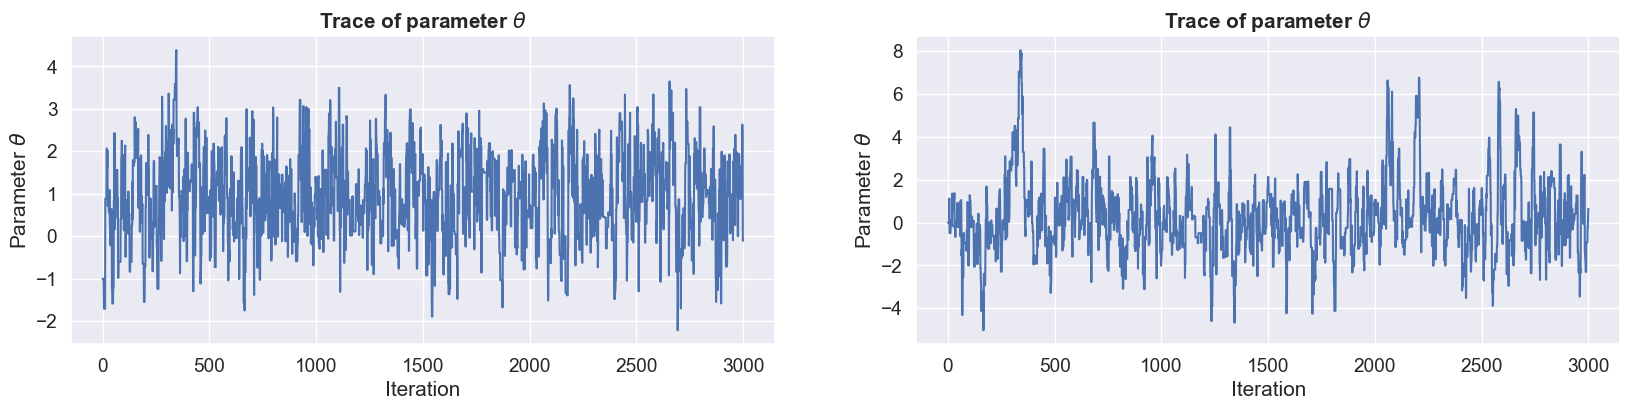

In [76]:
mcmc1.plot_trace()

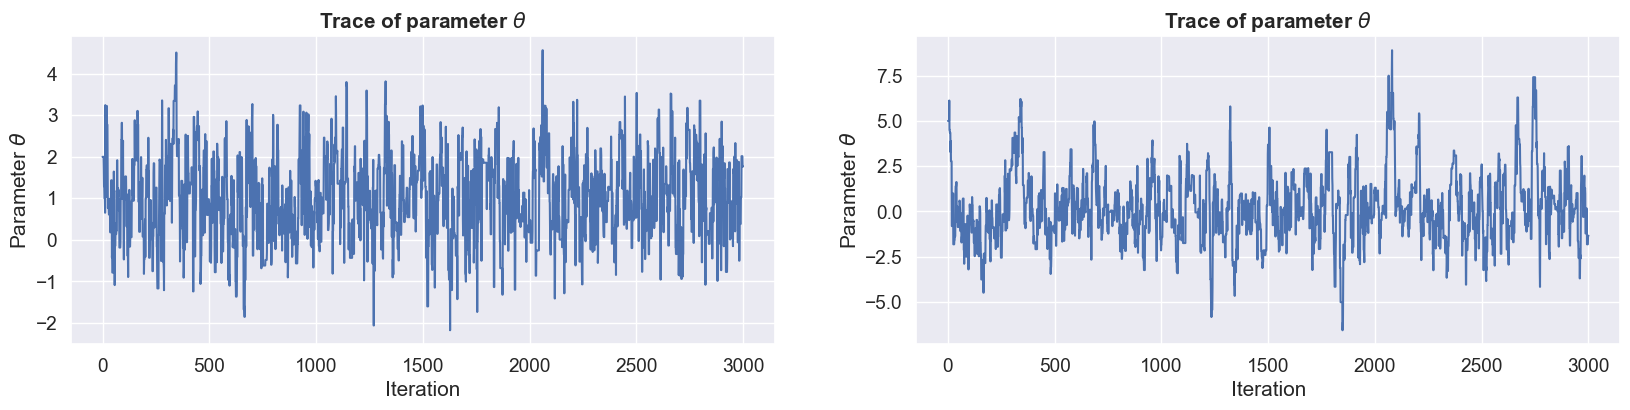

In [77]:
mcmc2.plot_trace()

## Question 5.2

In [78]:
thetas = jnp.vstack((mcmc1.thetas, mcmc2.thetas))

In [80]:
jnp.mean((thetas[:,0]- thetas[:,1])**2)

Array(4.2514014, dtype=float32)

## Question 5.3

In [81]:
jnp.mean(thetas[:,1] < 1)

Array(0.72509164, dtype=float32)